# 📘 Week 10: ML + Biomedical & Anomaly Detection
Welcome to Week 10! In this module, we will explore the intersection of **Signal Processing and Machine Learning** by building an end-to-end classification pipeline for Arrhythmia detection and applying unsupervised **Anomaly Detection** on ECG features.

## 🎯 Learning Objectives:
- Extract Heart Rate Variability (HRV) features—**SDNN** and **RMSSD**—from ECG RR-intervals.
- Construct a patient feature dataset for classification.
- Build, train, and evaluate a **supervised Random Forest Classifier** to distinguish healthy vs. Arrhythmia patients.
- Understand and implement **unsupervised Anomaly Detection** using **Isolation Forest** to detect ectopic/abnormal heartbeats.

## 1. Feature Extraction: Heart Rate Variability (HRV)
Heart Rate Variability (HRV) measures the variation in time between consecutive heartbeats (the **R-to-R intervals** or NN intervals). HRV is a powerful indicator of autonomic nervous system health.

### Key Time-Domain HRV Features:
1. **Mean RR**: Average interval between heartbeats (in seconds).
2. **SDNN**: Standard Deviation of NN (RR) intervals:
   $$\text{SDNN} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (RR_i - \overline{RR})^2}$$
3. **RMSSD**: Root Mean Square of Successive Differences:
   $$\text{RMSSD} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N-1} (RR_{i+1} - RR_i)^2}$$

Let's write a function to simulate RR intervals for a healthy individual and an Arrhythmia patient, then extract these features.

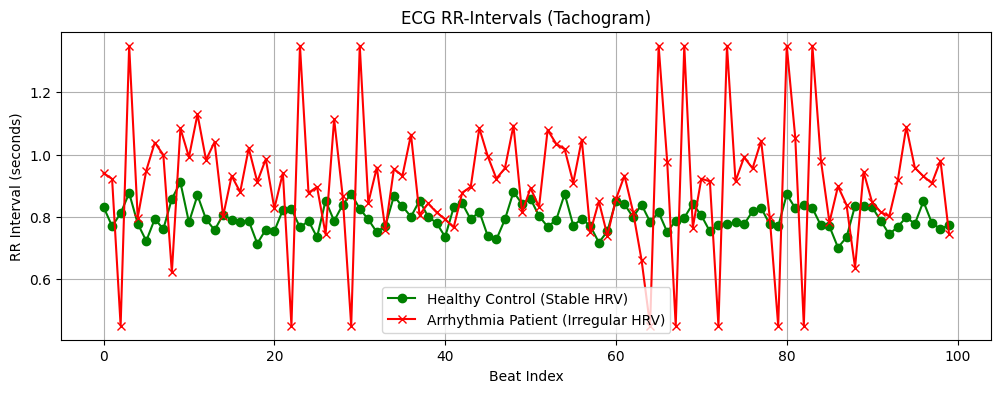

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

def simulate_rr_intervals(patient_type="healthy", num_beats=100):
    """
    Simulates RR intervals (in seconds) for a patient.
    - Healthy: Stable heart rate (mean RR ~ 0.8s) with slight respiratory variation.
    - Arrhythmia: Highly irregular intervals with sudden premature beats.
    """
    np.random.seed(None)  # Ensure randomness on every call
    if patient_type == "healthy":
        # Mean 0.8s (75 bpm), standard deviation 0.04s
        rr = np.random.normal(0.8, 0.04, num_beats)
        # Add some respiratory sinus arrhythmia (slow modulation)
        modulation = 0.03 * np.sin(2 * np.pi * 0.15 * np.arange(num_beats))
        rr += modulation
    else:
        # Irregular rate (mean 0.9s), high variance
        rr = np.random.normal(0.9, 0.12, num_beats)
        # Introduce Premature Ventricular Contractions (PVCs) -> sudden short RR followed by a compensatory pause
        pvc_indices = np.random.choice(range(2, num_beats-2), size=8, replace=False)
        for idx in pvc_indices:
            rr[idx] = 0.45  # Sudden short interval
            rr[idx+1] = 1.35  # Compensatory pause
            
    return rr

# Simulate and plot RR intervals
healthy_rr = simulate_rr_intervals("healthy")
arrhythmia_rr = simulate_rr_intervals("arrhythmia")

plt.figure(figsize=(12, 4))
plt.plot(healthy_rr, label="Healthy Control (Stable HRV)", color='g', marker='o')
plt.plot(arrhythmia_rr, label="Arrhythmia Patient (Irregular HRV)", color='r', marker='x')
plt.title("ECG RR-Intervals (Tachogram)")
plt.xlabel("Beat Index")
plt.ylabel("RR Interval (seconds)")
plt.legend()
plt.grid(True)
plt.show()

## 2. Dataset Construction
Let's write a function to calculate `Mean_RR`, `SDNN`, and `RMSSD` for any given sequence of RR intervals.
Then, we will generate a simulated dataset of **100 patients** (50 Healthy Controls, 50 Arrhythmia Patients) to train our classifier.

In [2]:
def calculate_hrv_features(rr_intervals):
    """
    Computes time-domain HRV features
    """
    mean_rr = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals, ddof=1)
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))
    return mean_rr, sdnn, rmssd

# Construct the dataset
features = []
labels = []

# Generate 50 Healthy Controls (Label 0)
for _ in range(50):
    rr = simulate_rr_intervals("healthy")
    features.append(calculate_hrv_features(rr))
    labels.append(0)

# Generate 50 Arrhythmia Patients (Label 1)
for _ in range(50):
    rr = simulate_rr_intervals("arrhythmia")
    features.append(calculate_hrv_features(rr))
    labels.append(1)

# Convert to DataFrame
df = pd.DataFrame(features, columns=["Mean_RR", "SDNN", "RMSSD"])
df["Label"] = labels

print("Dataset Sample (First 5 rows - Healthy):")
print(df.head())
print("\nDataset Sample (Last 5 rows - Arrhythmia):")
print(df.tail())

Dataset Sample (First 5 rows - Healthy):
    Mean_RR      SDNN     RMSSD  Label
0  0.802770  0.039514  0.056948      0
1  0.798360  0.046894  0.063682      0
2  0.802461  0.050354  0.066987      0
3  0.801971  0.043462  0.058427      0
4  0.806116  0.045570  0.063072      0

Dataset Sample (Last 5 rows - Arrhythmia):
     Mean_RR      SDNN     RMSSD  Label
95  0.898349  0.211019  0.346953      1
96  0.903694  0.195817  0.308675      1
97  0.913393  0.218460  0.350074      1
98  0.886394  0.204204  0.349961      1
99  0.910671  0.209650  0.360379      1


## 3. Supervised Classification Pipeline
Now we will build a classification model to detect arrhythmia based on our time-domain HRV features:
1. Split the dataset into **Train (80%)** and **Test (20%)** sets.
2. Train a **Random Forest Classifier**.
3. Evaluate the model using a classification report (precision, recall, F1-score) and a confusion matrix.

Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        10
  Arrhythmia       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



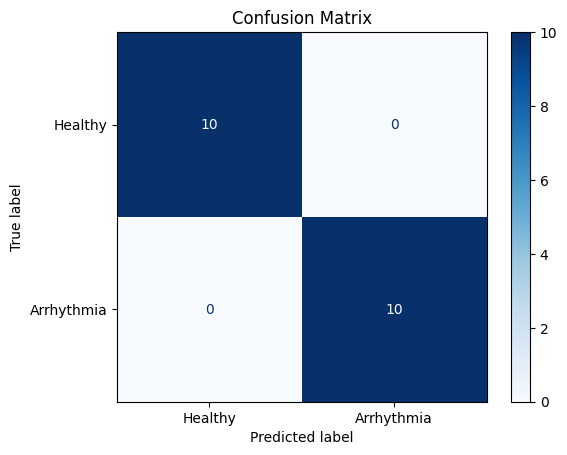

In [3]:
X = df[["Mean_RR", "SDNN", "RMSSD"]]
y = df["Label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Healthy", "Arrhythmia"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Arrhythmia"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## 4. Unsupervised Anomaly Detection (Isolation Forest)
Sometimes, we don't have labels for healthy/unhealthy patients, or we want to detect abnormal heartbeats (e.g. PVCs) on a single patient stream. This can be modeled as an **anomaly detection** task.

An **Isolation Forest** isolates observations by randomly selecting a feature and split value. Anomalies require fewer splits to isolate (closer to the root of the tree) compared to normal data.

Let's simulate a stream of 120 beats where 8 are anomalies (abnormally short/long intervals) and detect them.

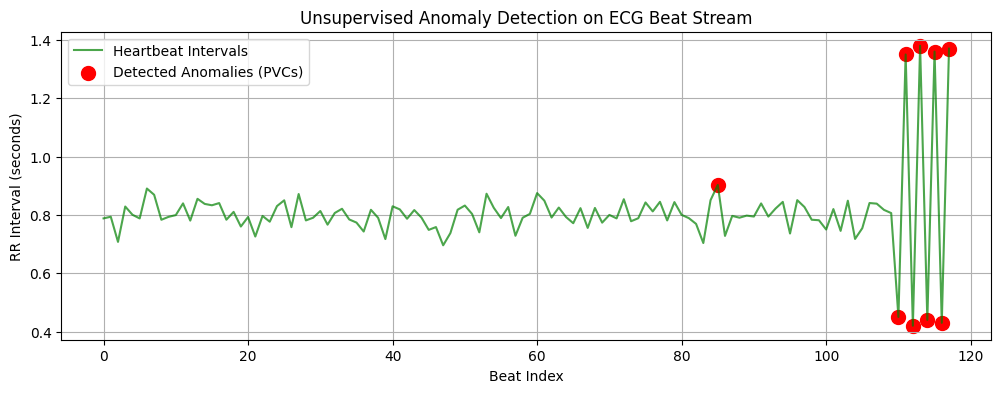

In [4]:
# Generate normal heartbeat intervals (Mean ~ 0.8s, SD ~ 0.04s)
normal_beats = np.random.normal(0.8, 0.04, 110)

# Generate anomalous beats (ectopic PVC beats and compensatory pauses)
anomalous_beats = np.array([0.45, 1.35, 0.42, 1.38, 0.44, 1.36, 0.43, 1.37])

# Combine and reshape for model input
all_beats = np.concatenate([normal_beats, anomalous_beats])
all_beats_reshaped = all_beats.reshape(-1, 1)

# Fit Isolation Forest
# contamination=0.08 represents the expected fraction of outliers in the data
iso_forest = IsolationForest(contamination=0.07, random_state=42)
preds = iso_forest.fit_predict(all_beats_reshaped)

# Predictions: -1 is an anomaly, 1 is normal
anomalies_indices = np.where(preds == -1)[0]

# Plot the beats and highlight detected anomalies
plt.figure(figsize=(12, 4))
plt.plot(all_beats, label="Heartbeat Intervals", color='g', alpha=0.7)
plt.scatter(anomalies_indices, all_beats[anomalies_indices], color='r', marker='o', s=100, label="Detected Anomalies (PVCs)")
plt.title("Unsupervised Anomaly Detection on ECG Beat Stream")
plt.xlabel("Beat Index")
plt.ylabel("RR Interval (seconds)")
plt.legend()
plt.grid(True)
plt.show()

## ✅ Reflection & Exercises
- **Feature Importance:** Random Forests allow us to look at which features were most helpful for classification. Check `clf.feature_importances_` to see if `Mean_RR`, `SDNN`, or `RMSSD` is the strongest predictor.
- **Isolation Forest Contamination:** What happens to the anomaly detector's predictions if we change `contamination` to `0.02`? Try it and observe if it misses some true anomalies.